In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
# !pip install mkl
# import mkl

# mkl.set_num_threads(2)
np.random.seed(1234)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

### Handy utility functions

In [2]:
def append_ones(matrix, axis=1):
    return np.concatenate((matrix, np.ones((matrix.shape[0], 1), dtype=np.float32)), axis=axis)

def zeros(*dims):
    return np.zeros(shape=tuple(dims), dtype=np.float32)

def ones(*dims):
    return np.ones(shape=tuple(dims), dtype=np.float32)

def rand(*dims):
    return np.random.rand(*dims).astype(np.float32)

def randn(*dims):
    return np.random.randn(*dims).astype(np.float32)

def chunks(seq, size):
    return (seq[pos:pos + size] for pos in range(0, len(seq), size))

def as_matrix(vector):
    return np.reshape(vector, (-1, 1))

def one_hot_encode(labels):
    one_hot = zeros(labels.shape[0], np.max(labels) + 1) 
    one_hot[np.arange(labels.shape[0]), labels] = 1
    return one_hot.astype(np.float32)

def classify(mlp, batch):
    probabilities, _ = forward_pass(mlp, batch, False)
    return np.argmax(probabilities, axis=1)

def tiles(examples):
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]
    
    space_between_tiles = 2
    img_matrix = np.empty(shape=(rows_count * (tile_height + space_between_tiles) - space_between_tiles,  
                                 cols_count * (tile_width + space_between_tiles) - space_between_tiles))
    img_matrix.fill(np.nan)

    for r in range(rows_count):
        for c in range(cols_count):
            x_0 = r * (tile_height + space_between_tiles)
            y_0 = c * (tile_width + space_between_tiles)
            ex_min = np.min(examples[r, c])
            ex_max = np.max(examples[r, c])
            img_matrix[x_0:x_0 + tile_height, y_0:y_0 + tile_width] = (examples[r, c] - ex_min) / (ex_max - ex_min)
    
    plt.matshow(img_matrix, cmap='gray', interpolation='none')
    plt.axis('off')
    plt.show()

def draw_layer_filters(layer):
    filters = np.reshape(layer.W[:-1].T, newshape=(16, -1, 28, 28))
    tiles(filters)

### Activation functions

In [3]:
def sigmoid(batch, stochastic=False):
    activations = 1.0 / (1.0 + np.exp(-batch))
    if stochastic:
        return activations > rand(*activations.shape).astype(np.float32)
    else:
        return activations

def sigmoid_derivative(batch):
    s = sigmoid(batch)
    return s * (1.0 - s)

def softmax(batch: np.ndarray) -> np.ndarray:
    # TODO implement
    # raise Exception('Softmax activation function is not implemented!')
    shifted = batch - np.max(batch, axis=1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values, axis=1, keepdims=True)

In [4]:
# przekopiowane z Lab 8
def relu(batch: np.ndarray, stochastic: bool = False) -> np.ndarray:
    """
    Stochastic ReLU
    """
    # TODO implement
    # raise Exception("Not implemented!")
    activations = np.maximum(0.0, batch)

    if stochastic:
        noise_std = np.sqrt(sigmoid(batch))
        noise = np.random.normal(
            loc=0.0,
            scale=noise_std,
            size=batch.shape
        ).astype(np.float32)

        activations = activations + noise

    return activations.astype(np.float32)

def relu_derivative(batch: np.ndarray) -> np.ndarray:
    """
    ReLU derivative
    """
    # TODO implement
    # raise Exception("Not implemented!")
    return (batch > 0).astype(np.float32)

# MNIST dataset

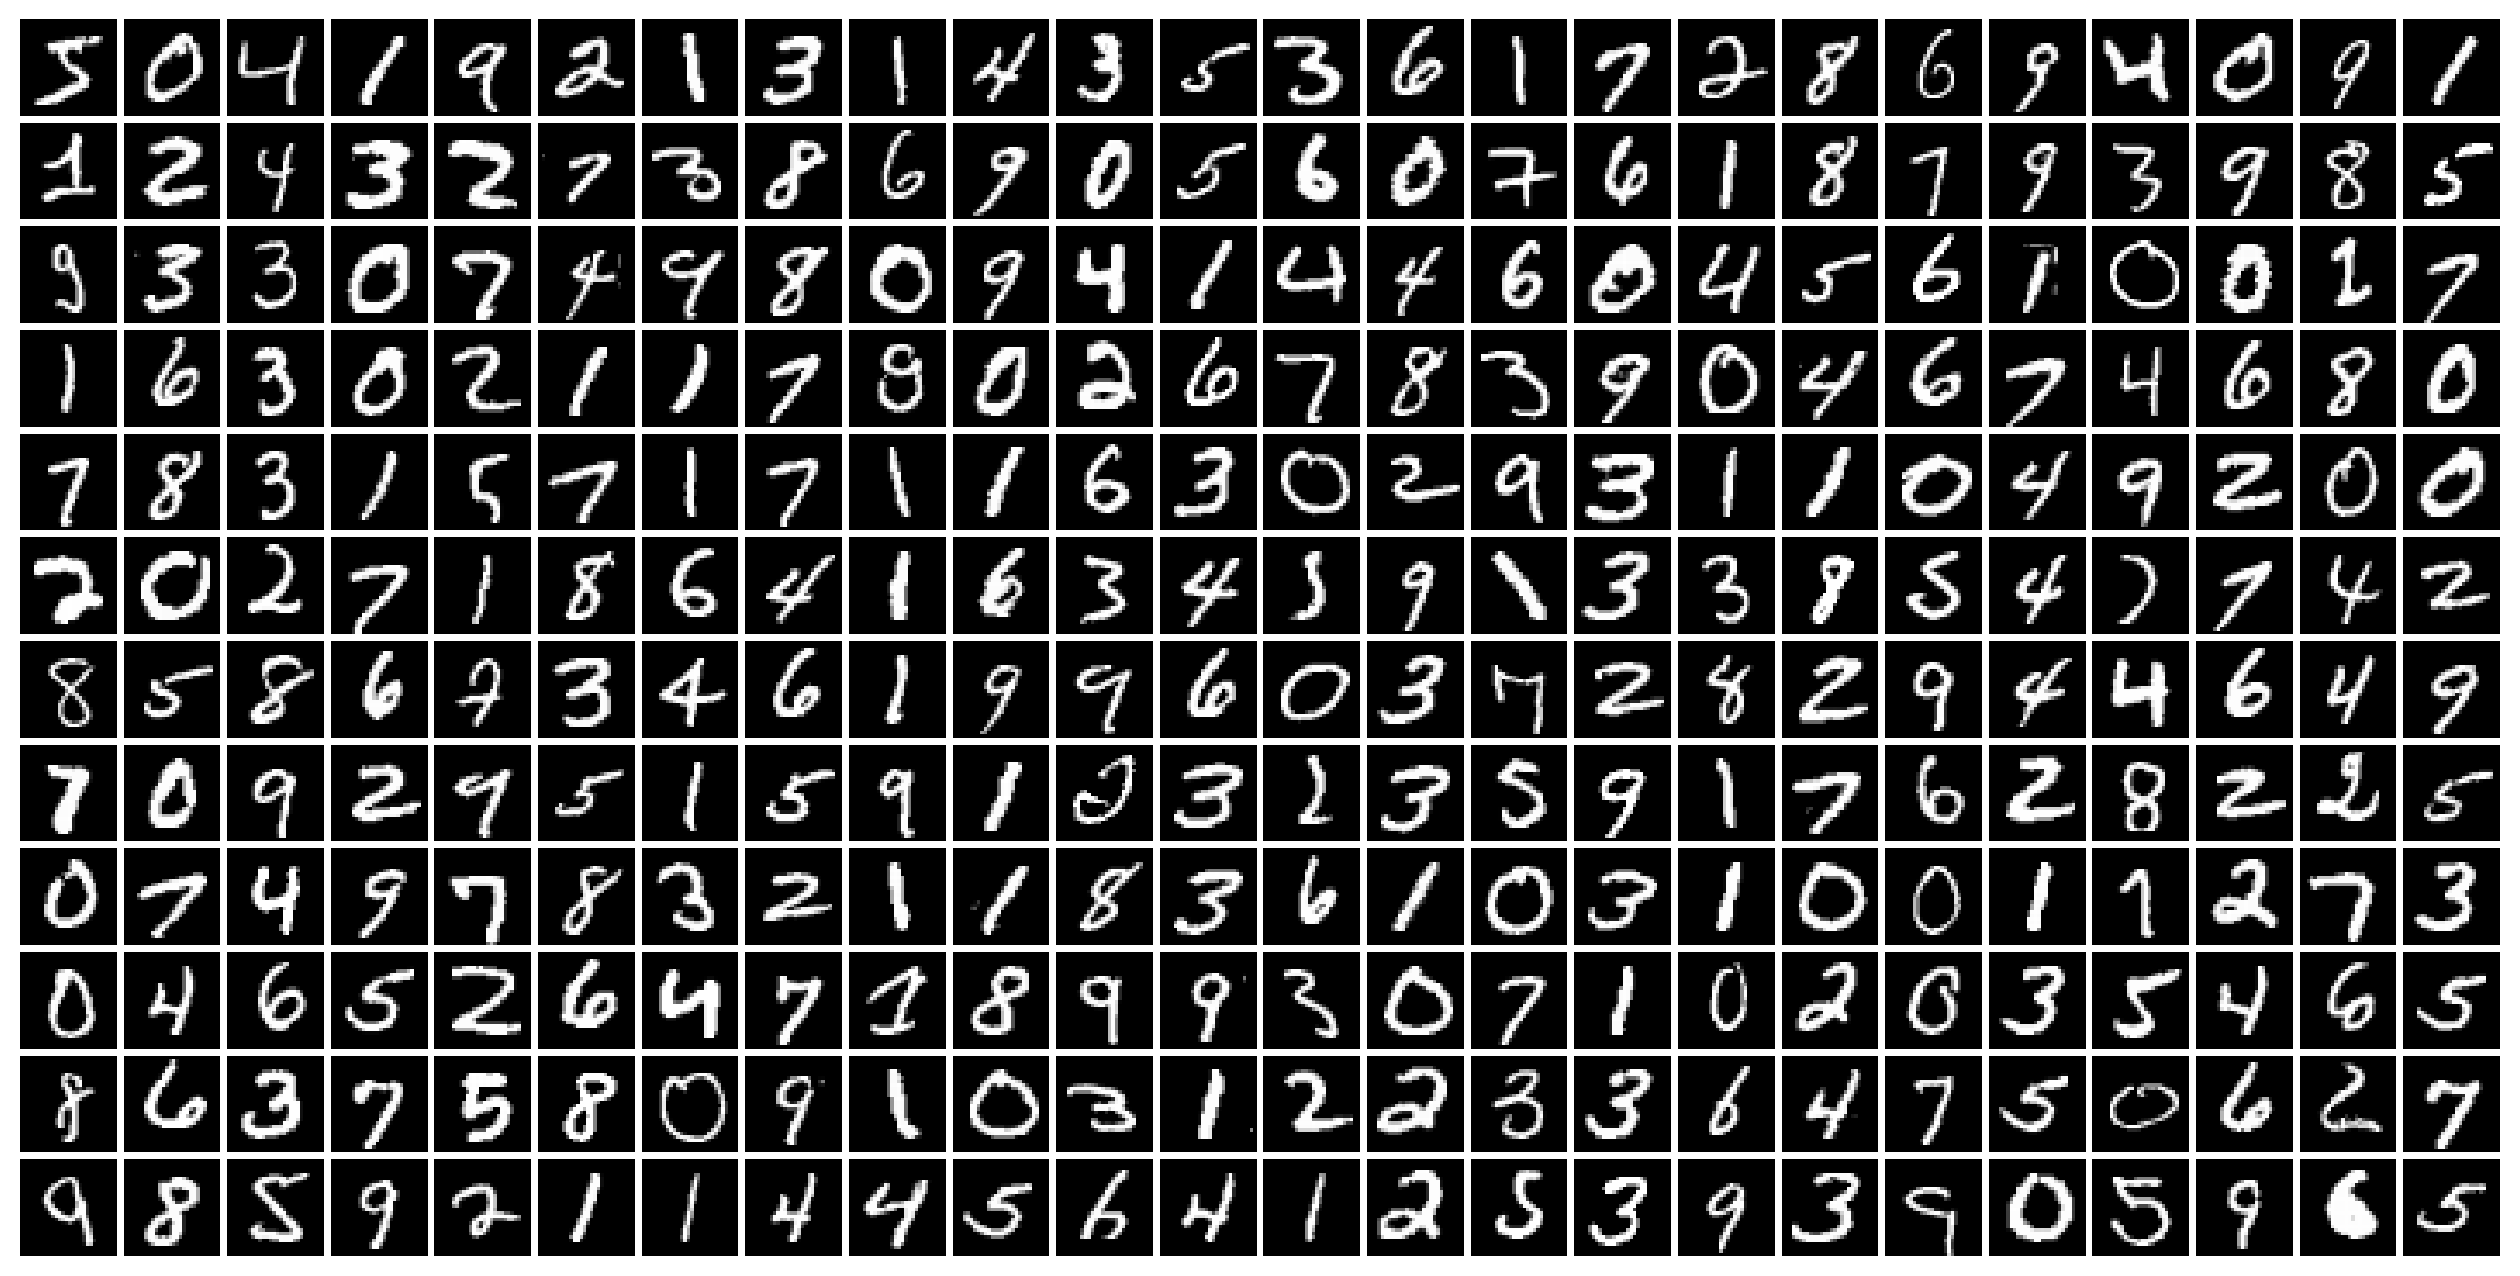

In [8]:
from mnists import MNIST
mnist = MNIST()
digits = np.reshape(mnist.train_images()[:12*24], shape=(12, 24, 28, 28))
tiles(digits)

# MLP training

In [9]:
class Layer:
    def __init__(self, visible_size, hidden_size, activation_fun, d_activation_fun, 
                 dropout_rate, learning_rate, momentum, weight_limit):
        self.visible_size = visible_size
        self.hidden_size = hidden_size
        
        self.activation_fun = activation_fun
        self.d_activation_fun = d_activation_fun
        
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.momentum = momentum
        
        self.weight_limit = weight_limit
        
        self.reset()
    
    def reset(self):
        self.W = np.random.normal(scale=0.01, size=(self.visible_size+1, self.hidden_size)).astype(np.float32)
        self.W[-1, :] = 0.0
        
        self.activations = None
        self.d_activations = None
        self.deltas = None
        
        self.M = zeros(self.visible_size+1, self.hidden_size)
        
    def deep_copy(self):
        copy = Layer(self.visible_size, self.hidden_size, self.activation_fun, self.d_activation_fun,
                     self.dropout_rate, self.learning_rate, self.momentum, self.weight_limit)
        copy.W = np.copy(self.W)
        copy.M = np.copy(self.M)
        return copy

In [10]:
def limit_weights(weights, limit):
    # TODO implement
    # raise Exception("Not implemented!")

    if limit == 0:
        return weights

    column_norms = np.linalg.norm(weights, ord=2, axis=0, keepdims=True)
    scale = np.minimum(1.0, limit / column_norms)

    return (weights * scale).astype(np.float32)

### Forward pass

Calculate total input to the neurons. Then calculate activations (remember to add *ones* as the last column). Store result in `layer.activations`.

##### Computing derivatives of activation function

If `compute_derivatives` is set to `True`, we also need to compute the derivatives of the activation function and store them in `layer.d_activations`. We **do not** need to add *ones column* to the derivatives matrix! *Ones* are only needed in the activations matrix, where they are used to add biases to the total input of neurons in the next hidden layer.

##### Dropout

If `compute_derivatives` is set to `True` and the dropout rate in the input layer is greater than 0, we need to calculate the dropout mask for the MLP input and apply it to `batch`.

When calculating hidden activations in an MLP layer, check whether dropout rate in the next layer is greater then 0. If yes, then we need to apply dropout to the calculated activations (and derivatives of activations). In this case:
* construct dropout mask for the hidden layer,
* apply this mask to where it is needed in the hidden layer.

Do **not** apply dropout to the last column in activations or input batch, as they contains fixed *ones*.

In [11]:
def forward_pass(mlp, batch, compute_derivatives):    
    if compute_derivatives and mlp[0].dropout_rate > 0:
        batch = np.copy(batch)
        
        # raise Exception("Dropout in the forward pass is not implemented!")
        #
        # apply dropout to the MLP input
        #
        dropout_mask = rand(*batch.shape) > mlp[0].dropout_rate
        dropout_mask[:, -1] = True  # do not drop bias column
        batch *= dropout_mask
        
    visible = batch
    
    for layer_idx, layer in enumerate(mlp):
        # raise Exception('Compute layer activations here!')
        # z = ???
        # layer.activations = ???
        z = visible @ layer.W
        layer.activations = append_ones(layer.activation_fun(z))
        
        if compute_derivatives and (layer_idx < len(mlp) - 1):
            # raise Exception('Remember about the derivatives of the activation function!')
            # layer.d_activations = ???
            layer.d_activations = layer.d_activation_fun(z)
            
            if mlp[layer_idx + 1].dropout_rate > 0:
                # raise Exception("Dropout in the forward pass is not implemented!")
                #
                # apply dropout where is it needed in the hidden layer
                #
                dropout_mask = rand(*layer.activations.shape) > mlp[layer_idx + 1].dropout_rate
                dropout_mask[:, -1] = True  # do not drop bias column
                
                layer.activations *= dropout_mask
                layer.d_activations *= dropout_mask[:, :-1]
        
        visible = layer.activations
    
    return visible[:, :-1], batch

### Error backpropagation

In [12]:
# skopiownae z Laba 8
def error_backpropagate(mlp, batch):
    observations_count = batch.shape[0]
    
    # error('Error backpropagation is unimplemented')
    
    for layer_idx, layer in reversed(list(enumerate(mlp))):
        if layer_idx > 0:
            prev_layer = mlp[layer_idx - 1]
            visible = prev_layer.activations
            
            # raise Exception("Calculate the deltas in 'prev_layer'")
            # prev_layer.deltas = ???
            prev_layer.deltas = (
                (layer.deltas @ layer.W[:-1, :].T) * prev_layer.d_activations
            )
        else:
            visible = batch
        
        # raise Exception("Update the momentum matrix with gradient from error backpropagation")
        # layer.M = ???
        layer.M = (
            layer.momentum * layer.M
            - (layer.learning_rate / observations_count) * (visible.T @ layer.deltas)
        )
        
        layer.W += layer.M
        
        if layer.weight_limit > 0.0:
            layer.W[:-1, :] = limit_weights(layer.W[:-1, :], layer.weight_limit)

### Mean dropout network

Implement the weight scalling for the network that approximates MLP outputs under dropout.

In [14]:
def mean_network(mlp):
    mlp = [layer.deep_copy() for layer in mlp]
    
    for layer in mlp:
        # raise Exception("Mean dropout network is not implemented!")
        layer.W[:-1, :] *= (1.0 - layer.dropout_rate)
    
    return mlp

### Training procedure

In [15]:
# skopiowane z Lab 8
def train_mlp(mlp, dataset, labels, batch_size):
    batches_limit = dataset.shape[0] / batch_size
    
    batched_data = chunks(dataset, batch_size)
    batched_labels = chunks(labels, batch_size)

    progress_step = max(1, round(batches_limit / 40))
    
    for batch_idx, (batch, batch_labels) in enumerate(zip(batched_data, batched_labels)):
        # Forward pass: compute activatations and derivatives of activations
        y, batch_with_dropout = forward_pass(mlp, batch, True)
        
        # raise Exception("Delta in the sofmax layer is unimplemented!")
        # mlp[-1].deltas = ??
        mlp[-1].deltas = y - batch_labels
        
        # Once softmax deltas are set, we may backpropagate errors
        error_backpropagate(mlp, batch_with_dropout)
        
        if batch_idx % progress_step == 0:
            print("#", end="")

In [16]:
def run_mlp_training(mlp, train_set, train_labels, validation_set, validation_labels,
                     batch_size, epochs_count):
    for epoch in range(epochs_count):
        print("Epoch {}:".format(epoch+1),  end="\t")
        
        if epoch == 5:
            for layer in mlp:
                layer.momentum = 0.95
                layer.learning_rate = 0.15
        elif epoch == 150:
            for layer in mlp:
                layer.momentum = 0.925
                layer.learning_rate = 0.1
        elif epoch == 175:
            for layer in mlp:
                layer.momentum = 0.9
                layer.learning_rate = 0.01
                
        start_time = time.time()
        train_mlp(mlp, train_set, train_labels, batch_size)
        elapsed = time.time() - start_time
        
        test_mlp = mean_network(mlp)
        
        predictions = classify(test_mlp, validation_set)
        accuracy = 100.0 * np.sum(predictions == validation_labels) / predictions.shape[0]
        print("\telapsed: {0:>2.2f}s, accuracy: {1:>2.2f}".format(elapsed, accuracy))

    print("Training finished!")

# MNIST digits classification

In [22]:
#  'newshape' usuniete bo waliło errorami
DATASET_SIZE = 10_000 # 60000 for whole dataset
DIGIT_SIZE = 28

##### Train set #####

mnist_train_images = mnist.train_images().astype(np.float32) / 255.0
mnist_train_labels = mnist.train_labels()

order = np.random.permutation(len(mnist_train_images))
mnist_train_images = mnist_train_images[order]
mnist_train_labels = mnist_train_labels[order]

mnist_train_images = np.reshape(
    mnist_train_images[:DATASET_SIZE],
    (DATASET_SIZE, DIGIT_SIZE * DIGIT_SIZE)
)
mnist_train_images = append_ones(mnist_train_images)

mnist_train_labels = mnist_train_labels[:DATASET_SIZE]
mnist_train_labels = one_hot_encode(mnist_train_labels)

monitoring_set_indeces = np.random.choice(mnist_train_images.shape[0], 512, replace=False)
monitoring_set = mnist_train_images[monitoring_set_indeces]

##### Test set #####

mnist_test_images = mnist.test_images().astype(np.float32) / 255.0
mnist_test_images = np.reshape(
    mnist_test_images,
    (-1, DIGIT_SIZE * DIGIT_SIZE)
)
mnist_test_images = append_ones(mnist_test_images)

mnist_test_labels = mnist.test_labels()

In [23]:
VISIBLE_LAYER_SIZE = DIGIT_SIZE*DIGIT_SIZE
HIDDEN_LAYER_SIZE = 1024

BATCH_SIZE = 128
EPOCHS_COUNT = 200

LEARNING_RATE = 0.03
SOFTMAX_LEARNING_RATE = 0.15
MOMENTUM = 0.5

In [24]:
from IPython.core.display import HTML

def evaluate(mlp, train_set, train_labels,
             validation_set, validation_labels,
             batch_size, epochs_count):
    for layer in mlp:
        layer.reset()

    display(HTML('<h3>MLP training</h3>'))
    run_mlp_training(mlp,
                     train_set, train_labels,
                     validation_set, validation_labels,
                     batch_size, epochs_count)
    
    display(HTML('<h3>Input layer filters in MLP</h3>'))
    draw_layer_filters(mlp[0])
    
    display(HTML('<h3>Largest norms of weight-vectors in MLP layers</h3>'))
    for i, layer in enumerate(mlp):
        max_norm = np.max(np.linalg.norm(layer.W[:-1, :], axis=0))
        print('\tlayer {0}: {1:.2f}'.format(i+1, max_norm))

### Plain MLP (no dropout)

In [25]:
mlp = [
    Layer(VISIBLE_LAYER_SIZE, HIDDEN_LAYER_SIZE, relu, relu_derivative, 0.0, LEARNING_RATE, MOMENTUM,
          weight_limit=2.0),
    Layer(HIDDEN_LAYER_SIZE, HIDDEN_LAYER_SIZE, relu, relu_derivative, 0.0, LEARNING_RATE, MOMENTUM,
          weight_limit=2.0),
    Layer(HIDDEN_LAYER_SIZE, 10, softmax, None, 0.0, SOFTMAX_LEARNING_RATE, MOMENTUM,
          weight_limit=2.5)
]

evaluate(mlp, 
         mnist_train_images, mnist_train_labels, 
         mnist_test_images, mnist_test_labels,
         BATCH_SIZE, EPOCHS_COUNT)

Epoch 1:	########################################	elapsed: 1.38s, accuracy: 54.45
Epoch 2:	########################################	elapsed: 1.39s, accuracy: 73.71
Epoch 3:	########################################	elapsed: 1.41s, accuracy: 83.47
Epoch 4:	########################################	elapsed: 1.48s, accuracy: 87.58
Epoch 5:	########################################	elapsed: 1.42s, accuracy: 89.42
Epoch 6:	########################################	elapsed: 1.43s, accuracy: 91.14
Epoch 7:	########################################	elapsed: 1.42s, accuracy: 93.59
Epoch 8:	########################################	elapsed: 1.43s, accuracy: 94.24
Epoch 9:	########################################	elapsed: 1.40s, accuracy: 93.81
Epoch 10:	########################################	elapsed: 1.42s, accuracy: 94.14
Epoch 11:	########################################	elapsed: 2.18s, accuracy: 94.07
Epoch 12:	########################################	elapsed: 1.48s, accuracy: 94.64
Epoch 13:	###

TypeError: reshape() got an unexpected keyword argument 'newshape'

## SZYBKA POPRAWKA

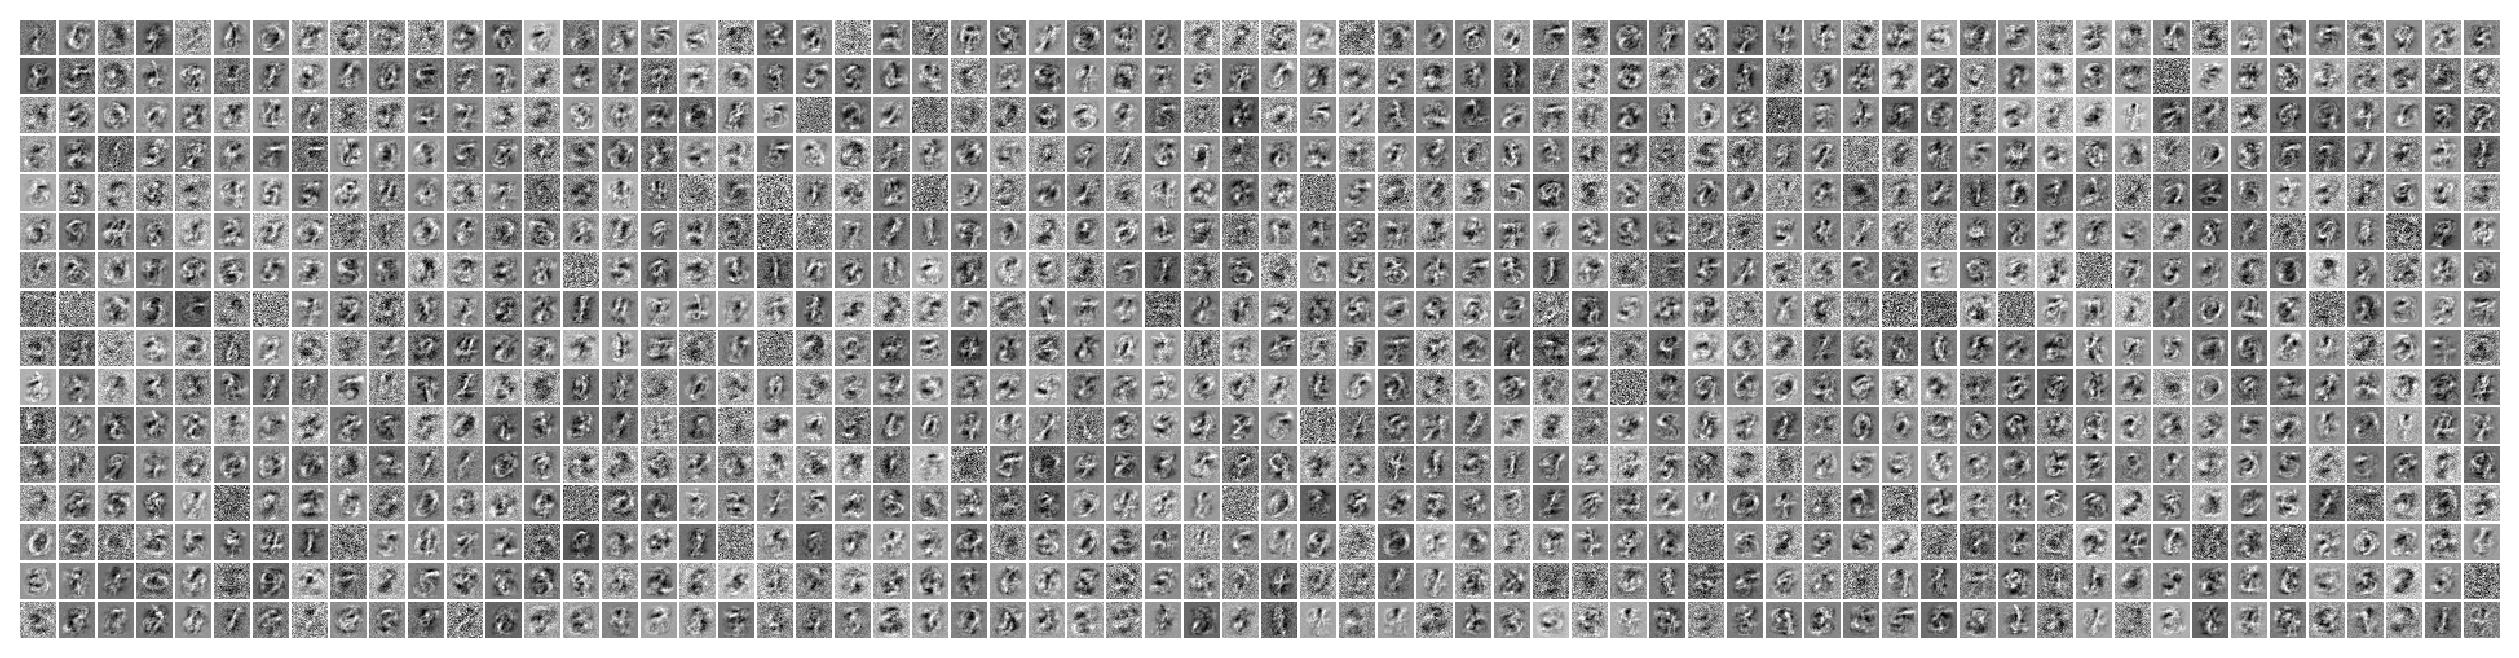

	layer 1: 2.00
	layer 2: 2.00
	layer 3: 2.50


In [26]:
def draw_layer_filters(layer):
    filters = np.reshape(layer.W[:-1].T, (16, -1, 28, 28))
    tiles(filters)

display(HTML('<h3>Input layer filters in MLP</h3>'))
draw_layer_filters(mlp[0])

display(HTML('<h3>Largest norms of weight-vectors in MLP layers</h3>'))
for i, layer in enumerate(mlp):
    max_norm = np.max(np.linalg.norm(layer.W[:-1, :], axis=0))
    print('\tlayer {0}: {1:.2f}'.format(i+1, max_norm))

### MLP with dropout

Epoch 1:	########################################	elapsed: 1.78s, accuracy: 11.35
Epoch 2:	########################################	elapsed: 2.35s, accuracy: 11.35
Epoch 3:	########################################	elapsed: 1.68s, accuracy: 11.48
Epoch 4:	########################################	elapsed: 1.86s, accuracy: 28.27
Epoch 5:	########################################	elapsed: 1.95s, accuracy: 29.12
Epoch 6:	########################################	elapsed: 1.90s, accuracy: 85.26
Epoch 7:	########################################	elapsed: 1.83s, accuracy: 92.07
Epoch 8:	########################################	elapsed: 2.25s, accuracy: 94.12
Epoch 9:	########################################	elapsed: 1.97s, accuracy: 93.61
Epoch 10:	########################################	elapsed: 1.75s, accuracy: 94.78
Epoch 11:	########################################	elapsed: 1.99s, accuracy: 95.51
Epoch 12:	########################################	elapsed: 2.07s, accuracy: 95.81
Epoch 13:	###

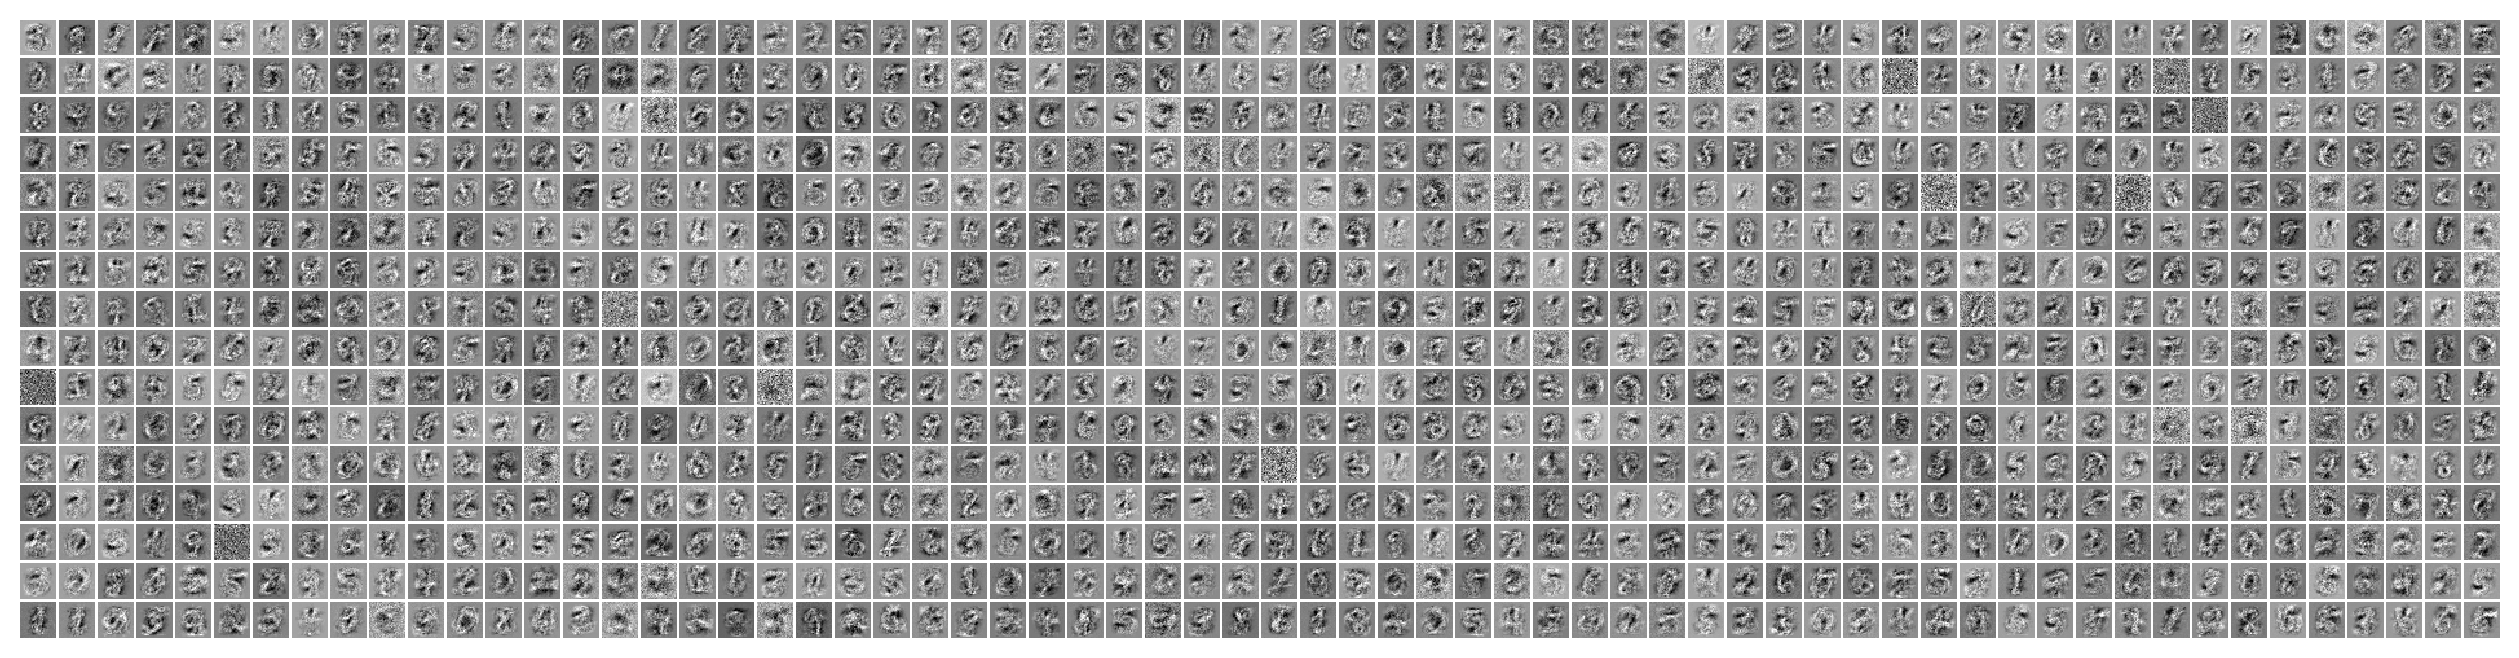

	layer 1: 2.00
	layer 2: 2.00
	layer 3: 2.50


In [27]:
mlp_with_dropout = [
    Layer(VISIBLE_LAYER_SIZE, HIDDEN_LAYER_SIZE, relu, relu_derivative, 0.2, LEARNING_RATE, MOMENTUM,
          weight_limit=2.0),
    Layer(HIDDEN_LAYER_SIZE, HIDDEN_LAYER_SIZE, relu, relu_derivative, 0.5, LEARNING_RATE, MOMENTUM,
          weight_limit=2.0),
    Layer(HIDDEN_LAYER_SIZE, 10, softmax, None, 0.5, SOFTMAX_LEARNING_RATE, MOMENTUM,
          weight_limit=2.5)
]

evaluate(mlp_with_dropout, 
         mnist_train_images, mnist_train_labels, 
         mnist_test_images, mnist_test_labels,
         BATCH_SIZE, EPOCHS_COUNT)